# GFlowNet Long Sequence Generation (10bp)

TB vs FL-DB comparison for 10bp RNA sequences.

In [ ]:
import time
import torch
import matplotlib.pyplot as plt

from gfn import train_fast, FastTrainingConfig
from gfn.reward import TargetMatchReward, HammingReward, EntropyWeightedHammingReward, AdaptiveHammingReward

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

## Environment Configuration (10bp)

In [ ]:
print(f"State space size: 4^10 = {4**10:,} possible sequences")

## Target Sequences

In [ ]:
from data.targets_10bp import TARGET_SEQUENCES_LIST as target_sequences

print(f"Number of targets: {len(target_sequences)}")
print(f"Target hit probability (random): {len(target_sequences) / 4**10 * 100:.6f}%")
print(f"\nFirst 10 target sequences:")
for seq in target_sequences[:10]:
    print(f"  {''.join(seq)}")
print(f"  ... ({len(target_sequences) - 10} more)")

## TB Training

In [ ]:
reward_fn = TargetMatchReward(target_sequences, r_min=0.1)

tb_config = FastTrainingConfig(
    alphabet=['A', 'U', 'G', 'C'],
    max_seq_len=10,
    seed=42,
    hidden_layers=[64, 64, 32],
    batch_size=2048,
    n_iterations=50,
    learning_rate=3e-3,
    device='cuda',
    objective='TB',
    target_sequences=target_sequences,
    explore_ratio=0.1,
    temperature=1.0,
)

print(f"TB config: {tb_config.max_seq_len}bp, {tb_config.n_timesteps} timesteps")
print(f"Total episodes: {tb_config.batch_size * tb_config.n_iterations:,}")
print(f"Exploration: eps={tb_config.explore_ratio}, T={tb_config.temperature}")

In [ ]:
tb_start = time.time()
tb_result = train_fast(reward_fn, tb_config, verbose=True)
tb_time = time.time() - tb_start

print(f"\nTB completed in {tb_time:.2f}s, Z={tb_result.final_Z:.2f}")
if tb_result.hit_rates:
    print(f"Final hit rate = {tb_result.final_hit_rate*100:.4f}%")

## FL-DB Training

In [ ]:
REWARD_SCHEME = 'entropy'

ENTROPY_WEIGHT = 1.0
DECAY_RATE = 0.5
MIN_MULTIPLIER = 0.1

print(f"Reward scheme: {REWARD_SCHEME}")

In [ ]:
if REWARD_SCHEME == 'basic':
    hamming_reward_fn = HammingReward(
        target_sequences,
        alphabet=['A', 'U', 'G', 'C'],
        r_min=0.1,
        device='cuda',
    )
elif REWARD_SCHEME == 'entropy':
    hamming_reward_fn = EntropyWeightedHammingReward(
        target_sequences,
        alphabet=['A', 'U', 'G', 'C'],
        r_min=0.1,
        device='cuda',
        entropy_weight=ENTROPY_WEIGHT,
    )
elif REWARD_SCHEME == 'adaptive':
    hamming_reward_fn = AdaptiveHammingReward(
        target_sequences,
        alphabet=['A', 'U', 'G', 'C'],
        r_min=0.1,
        device='cuda',
        decay_rate=DECAY_RATE,
        min_multiplier=MIN_MULTIPLIER,
    )
else:
    raise ValueError(f"Unknown reward scheme: {REWARD_SCHEME}")

print(f"Using: {type(hamming_reward_fn).__name__}")
print(f"GPU batch support: {hamming_reward_fn.supports_batch}, device: {hamming_reward_fn.device}")

In [ ]:
fldb_config = FastTrainingConfig(
    alphabet=['A', 'U', 'G', 'C'],
    max_seq_len=10,
    seed=42,
    hidden_layers=[64, 64, 32],
    batch_size=2048,
    n_iterations=50,
    learning_rate=3e-3,
    device='cuda',
    objective='FLDB',
    target_sequences=target_sequences,
    explore_ratio=0.3,
    temperature=2.0,
    insert_only=True,
)

print(f"FL-DB config: {fldb_config.max_seq_len}bp, {fldb_config.n_timesteps} timesteps")
print(f"Total episodes: {fldb_config.batch_size * fldb_config.n_iterations:,}")
print(f"Exploration: eps={fldb_config.explore_ratio}, T={fldb_config.temperature}")
print(f"Insert-only: {fldb_config.insert_only}")
print(f"Search space: {fldb_config.search_space_size:,} terminal states")

In [ ]:
fldb_start = time.time()
fldb_result = train_fast(hamming_reward_fn, fldb_config, verbose=True)
fldb_time = time.time() - fldb_start

print(f"\nFL-DB completed in {fldb_time:.2f}s, Z={fldb_result.final_Z:.2f}")
if fldb_result.hit_rates:
    print(f"Final hit rate = {fldb_result.final_hit_rate*100:.4f}%")

## Results

In [ ]:
print(f"{'Metric':<30} {'TB':<20} {'FL-DB':<20}")
print("-" * 70)
print(f"{'Total Episodes':<30} {tb_config.batch_size * tb_config.n_iterations:<20,} {fldb_config.batch_size * fldb_config.n_iterations:<20,}")
print(f"{'Training Time (s)':<30} {tb_time:<20.2f} {fldb_time:<20.2f}")
print(f"{'Time per 1K episodes (s)':<30} {tb_time/(tb_config.batch_size * tb_config.n_iterations)*1000:<20.4f} {fldb_time/(fldb_config.batch_size * fldb_config.n_iterations)*1000:<20.4f}")
print(f"{'Final Loss':<30} {tb_result.losses[-1]:<20.4f} {fldb_result.losses[-1]:<20.4f}")
print(f"{'Final Z':<30} {tb_result.final_Z:<20.2f} {fldb_result.final_Z:<20.2f}")

tb_hr = f"{tb_result.final_hit_rate*100:.4f}%" if tb_result.hit_rates else "N/A"
fldb_hr = f"{fldb_result.final_hit_rate*100:.4f}%" if fldb_result.hit_rates else "N/A"
print(f"{'Final Hit Rate':<30} {tb_hr:<20} {fldb_hr:<20}")

tb_cov = f"{tb_result.n_unique_targets_hit}/{tb_result.n_targets}" if tb_result.target_coverages else "N/A"
fldb_cov = f"{fldb_result.n_unique_targets_hit}/{fldb_result.n_targets}" if fldb_result.target_coverages else "N/A"
print(f"{'Target Coverage (cumulative)':<30} {tb_cov:<20} {fldb_cov:<20}")
print("-" * 70)

print(f"\nFL-DB is {fldb_time/tb_time:.1f}x slower than TB")

if tb_result.hit_rates and fldb_result.hit_rates:
    if fldb_result.final_hit_rate > tb_result.final_hit_rate:
        improvement = (fldb_result.final_hit_rate - tb_result.final_hit_rate) / tb_result.final_hit_rate * 100 if tb_result.final_hit_rate > 0 else float('inf')
        print(f"FL-DB hit rate is {improvement:.1f}% higher than TB")
    else:
        print(f"TB hit rate is higher or equal to FL-DB")

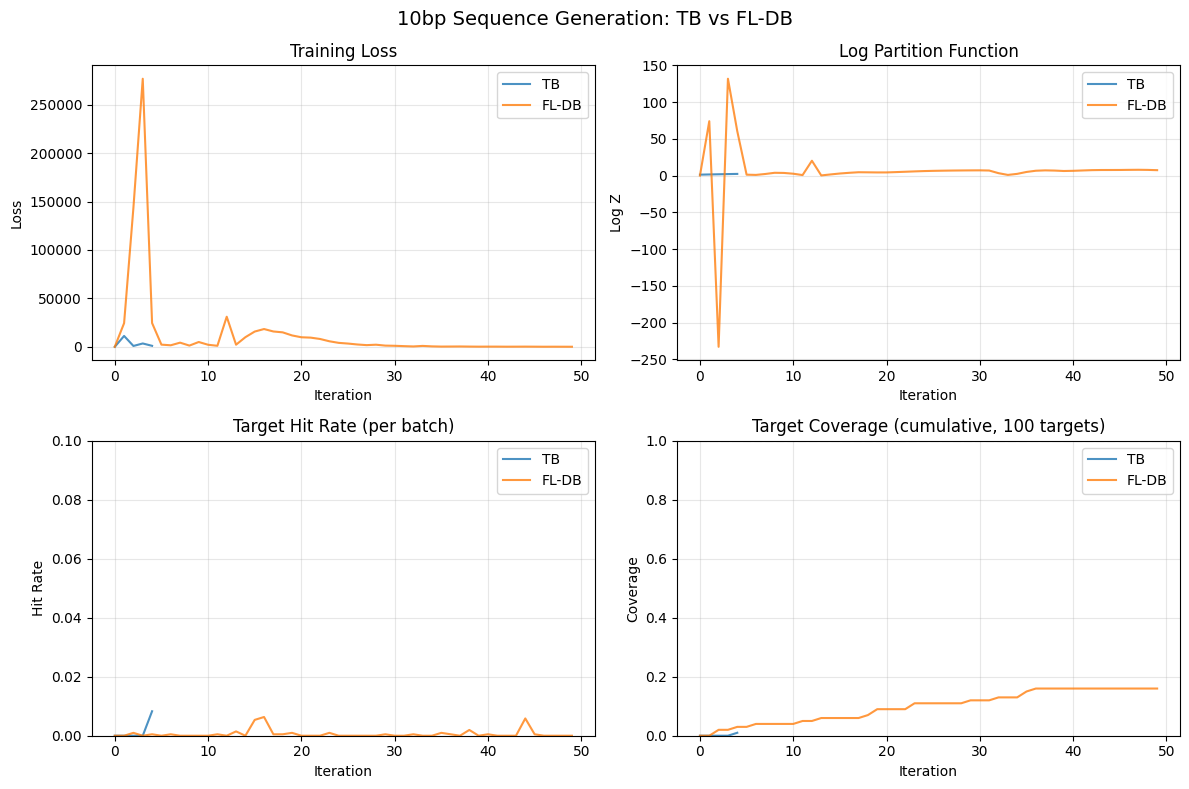

In [11]:
# Training curves comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loss
ax1 = axes[0, 0]
ax1.plot(tb_result.losses, label='TB', alpha=0.8)
ax1.plot(fldb_result.losses, label='FL-DB', alpha=0.8)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Log Z
ax2 = axes[0, 1]
ax2.plot(tb_result.logZs, label='TB', alpha=0.8)
ax2.plot(fldb_result.logZs, label='FL-DB', alpha=0.8)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Log Z')
ax2.set_title('Log Partition Function')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Hit Rate (per batch)
ax3 = axes[1, 0]
if tb_result.hit_rates:
    ax3.plot(tb_result.hit_rates, label='TB', alpha=0.8)
if fldb_result.hit_rates:
    ax3.plot(fldb_result.hit_rates, label='FL-DB', alpha=0.8)
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Hit Rate')
ax3.set_title('Target Hit Rate (per batch)')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, max(0.1, max(tb_result.hit_rates[-1] if tb_result.hit_rates else 0, 
                             fldb_result.hit_rates[-1] if fldb_result.hit_rates else 0) * 1.2))

# Target Coverage (cumulative)
ax4 = axes[1, 1]
if tb_result.target_coverages:
    ax4.plot(tb_result.target_coverages, label='TB', alpha=0.8)
if fldb_result.target_coverages:
    ax4.plot(fldb_result.target_coverages, label='FL-DB', alpha=0.8)
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Coverage')
ax4.set_title(f'Target Coverage (cumulative, {tb_result.n_targets} targets)')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 1.0)
ax4.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='100% coverage')

plt.suptitle('10bp Sequence Generation: TB vs FL-DB', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("TB Model (last 10 samples):")
for state in tb_result.sampled_states[-10:]:
    seq = ''.join(s for s in state[1] if s != 'ε')
    is_target = state[1] in target_sequences
    marker = " *" if is_target else ""
    print(f"  {seq}{marker}")

print("\nFL-DB Model (last 20 samples):")
for state in fldb_result.sampled_states[-20:]:
    seq = ''.join(s for s in state[1] if s != 'ε')
    is_target = state[1] in target_sequences
    marker = " *" if is_target else ""
    print(f"  {seq}{marker}")
    
print(len(fldb_result.sampled_states))

In [ ]:
from collections import Counter

lengths = [len([c for c in state[1] if c != 'ε']) for state in fldb_result.sampled_states]
length_counts = Counter(lengths)

print(f"Total samples: {len(lengths)}")
print(f"Length distribution: {dict(sorted(length_counts.items()))}")

# Check sample lengths across iterations
print("\nSample lengths by segment:")
for i in range(0, len(fldb_result.sampled_states), 100):
    segment = fldb_result.sampled_states[i:i+10]
    seg_lengths = [len([c for c in s[1] if c != 'ε']) for s in segment]
    print(f"  Samples {i}-{i+9}: lengths = {seg_lengths}")

## Save Results

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

tb_save_path = f'results/tb_10bp_{timestamp}'
tb_result.save(tb_save_path)

fldb_save_path = f'results/fldb_10bp_{timestamp}'
fldb_result.save(fldb_save_path)

print(f"Results saved with timestamp: {timestamp}")
print(f"  TB:    {tb_save_path}")
print(f"  FL-DB: {fldb_save_path}")

In [ ]:
print(f"[TB]")
if tb_result.hit_trajectories:
    tb_stats = tb_result.get_hit_stats()
    print(f"  Total hits: {tb_stats['total_hits']}")
    print(f"  Unique targets: {tb_stats['unique_targets']} / {tb_result.n_targets}")
else:
    print("  No hit trajectories recorded")

print(f"\n[FL-DB]")
if fldb_result.hit_trajectories:
    fldb_stats = fldb_result.get_hit_stats()
    print(f"  Total hits: {fldb_stats['total_hits']}")
    print(f"  Unique targets: {fldb_stats['unique_targets']} / {fldb_result.n_targets}")
    
    sorted_hits = sorted(fldb_stats['hits_per_target'].items(), key=lambda x: x[1], reverse=True)[:5]
    print(f"\n  Top 5 most frequently hit targets:")
    for seq, count in sorted_hits:
        print(f"    {seq}: {count} hits")
else:
    print("  No hit trajectories recorded")

In [ ]:
if REWARD_SCHEME == 'adaptive' and hasattr(hamming_reward_fn, 'get_hit_stats'):
    stats = hamming_reward_fn.get_hit_stats()
    print(f"Total hits registered: {stats['total_hits']}")
    print(f"Unique targets hit: {stats['unique_targets_hit']}")
    
    if stats['decay_multipliers']:
        print(f"\nTargets with decayed rewards:")
        for seq, mult in sorted(stats['decay_multipliers'].items(), key=lambda x: x[1])[:10]:
            print(f"  {seq}: multiplier = {mult:.3f}")